# [0.3] DESI Data: Import Whole Catalog

In [28]:
import glob
import os
from pathlib import Path

import lsdb
import nested_pandas as npd
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from dask.distributed import Client
from hats.io.validation import is_valid_catalog
from hats_import.catalog.arguments import ImportArguments
from hats_import.catalog.file_readers import InputReader
from hats_import.pipeline import pipeline_with_client

In [2]:
main_directory = Path("/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron")
core_redshift_catalog = main_directory / "zcatalog/v1/zall-pix-iron.fits"
spectra_directory = main_directory / "healpix/"

In [3]:
users_dir = Path("/global/cfs/cdirs/cosmo/users/")
target_user_dir = users_dir / "olynn"
os.makedirs(target_user_dir, exist_ok=True)

! tree -L 2 $users_dir

/global/cfs/cdirs/cosmo/users
├── cosmo
│   ├── archive_unwise_neo11.log
│   └── archive_unwise_neo9.log
├── olynn
│   └── desi-dr1-coadd-test
├── sjbailey
│   ├── dev
│   └── git
└── xiangchl
    ├── pdr3_dud_rev
    ├── pdr3_wide
    └── work

10 directories, 2 files


In [4]:
# Set up paths and arguments for the HATS import pipeline run.

base_path = spectra_directory
output_path = target_user_dir

print(f"Base path for input files: {base_path}")
print(f"Output path for HATS import: {output_path}")

Base path for input files: /global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix
Output path for HATS import: /global/cfs/cdirs/cosmo/users/olynn


In [5]:
print(spectra_directory)

# spectra_file = spectra_directory / "main/dark/0/0/spectra-main-dark-0.fits.gz"
redrock_file = spectra_directory / "main/dark/0/0/redrock-main-dark-0.fits"
coadd_file = spectra_directory / "main/dark/0/0/coadd-main-dark-0.fits"


/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix


## Redefine Custom Input Reader

(Now that we have a clearer sense on target data)

In [6]:
FIBERMAP_COLUMNS = [
    "TARGETID", # Main ID
    "TARGET_RA", "TARGET_DEC", # Spatial coordinates
]  # Note - we'll grab the nested spectra columns below
REDROCK_COLUMNS = [
    "TARGETID", # Main ID (matches fibermap)
    "Z", "ZERR" # Basic redshift information
    ]
# Could do EXP_FIBERMAPS's cols EXPID and NIGHT if desired (was a maybe in discussion).

class DesiCoaddReader(InputReader):

    def __init__(self, chunksize=500_000):
        self.chunksize = chunksize

    def read(self, input_file, read_columns=None):
        input_file = str(input_file)
        redrock_file = input_file.replace("coadd-", "redrock-")

        # Read fibermap from coadd (1 row per unique target).
        with fits.open(input_file, memmap=True) as hdul:
            fibermap = Table(hdul["FIBERMAP"].data)[FIBERMAP_COLUMNS].to_pandas()
            fibermap = fibermap.astype({col: fibermap[col].dtype.newbyteorder('=')
                                        for col in fibermap.columns})

        # Read redshifts info.
        with fits.open(redrock_file, memmap=True) as hdul:
            redshifts = Table(hdul['REDSHIFTS'].data)[REDROCK_COLUMNS].to_pandas()
            redshifts = redshifts.astype({col: redshifts[col].dtype.newbyteorder('=')
                                          for col in redshifts.columns})

        # Join and set TARGETID as index.
        joined = fibermap.merge(redshifts, on='TARGETID', how='left')
        joined = npd.NestedFrame(joined.set_index('TARGETID'))

        # Add nested spectra columns from coadd file.
        with fits.open(input_file, memmap=True) as hdul:
            for cam in ['B', 'R', 'Z']:
                wave = hdul[f'{cam}_WAVELENGTH'].data.astype('f8')
                flux = hdul[f'{cam}_FLUX'].data.astype('f4')  # (n_targets, n_wave)
                ivar = hdul[f'{cam}_IVAR'].data.astype('f4')
                mask = hdul[f'{cam}_MASK'].data.astype('i4')

                n_wave = len(wave)
                target_ids = joined.index

                flat = pd.DataFrame({
                    "wavelength": np.tile(wave, len(joined)),
                    "flux":       flux.ravel(),
                    "ivar":       ivar.ravel(),
                    "mask":       mask.ravel(),
                }, index=np.repeat(target_ids, n_wave))

                joined = joined.join_nested(flat, f"spectra_{cam.lower()}")

        yield joined


def get_desi_coadd_files(base_path, surveys=('main',), programs=('dark',)):
    """Glob all coadd files across surveys and programs."""
    files = []
    for survey in surveys:
        for program in programs:
            pattern = os.path.join(
                base_path, survey, program, '*', '*',
                f'coadd-{survey}-{program}-*.fits'
            )
            files.extend(glob.glob(pattern))
    return sorted(files)

## Run on small sample

In [20]:
# Remove any files in the output directory 
! tree -L 2 $output_path

! printf "\nRemoving files...\n\n"
! rm -rf $output_path/*
! tree $output_path

/global/cfs/cdirs/cosmo/users/olynn
├── desi-dr1-coadd-test
│   ├── dataset
│   ├── hats.properties
│   ├── partition_info.csv
│   ├── point_map.fits
│   ├── properties
│   └── skymap.fits
└── desi-dr1-main-dark
    └── intermediate

4 directories, 5 files

Removing files...

/global/cfs/cdirs/cosmo/users/olynn

0 directories, 0 files


In [21]:
base_path = '/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix'

test_files = [
    f'{base_path}/main/dark/0/0/coadd-main-dark-0.fits',
    f'{base_path}/main/dark/0/1/coadd-main-dark-1.fits',
]

output_catalog_name = 'desi-dr1-coadd-test'

args = ImportArguments(
    input_file_list=test_files,
    file_reader=DesiCoaddReader(),
    ra_column='TARGET_RA',
    dec_column='TARGET_DEC',
    output_artifact_name=output_catalog_name,
    output_path=output_path,
    pixel_threshold=5_000,
    resume=False,
)

# with Client(
#         n_workers=4,
#         memory_limit="4GB"
# ) as client:
#     pipeline_with_client(args, client)
pipeline_with_client(args, client)

Catalog: Mapping   :   0%|          | 0/2 [00:00<?, ?it/s]

Catalog: Finishing : 100%|██████████| 6/6 [00:00<00:00, 10.25it/s]


## Max out dask settings

In [15]:
!lscpu | grep -E "^CPU\(s\)|Thread|Core|Socket"

CPU(s):                                  256
Model name:                              AMD EPYC 7763 64-Core Processor
Thread(s) per core:                      2
Core(s) per socket:                      64
Socket(s):                               2
CPU(s) scaling MHz:                      69%


In [36]:
!scontrol show job $SLURM_JOB_ID | grep -E "CPU|mem"

   NumNodes=1 NumCPUs=256 NumTasks=1 CPUs/Task=1 ReqB:S:C:T=0:0:*:*
   ReqTRES=cpu=1,mem=487802M,node=1,billing=1
   AllocTRES=cpu=256,mem=487802M,node=1,billing=256
   MinCPUsNode=1 MinMemoryNode=0 MinTmpDiskNode=0


In [18]:
# Make a dask client
client = Client(
    n_workers=32,
    threads_per_worker=2,
    memory_limit="14GB",   # 32 × 14 = 448 GB, well within 487 GB
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 64,Total memory: 417.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33917,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33033,Total threads: 2
Dashboard: http://127.0.0.1:33505/status,Memory: 13.04 GiB
Nanny: tcp://127.0.0.1:40715,


In [42]:
# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.

import socket

username = os.getenv("USER")
current_compute_node = socket.gethostname()

print(f"1. In a local shell, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status")

1. In a local shell, run: ssh -L 8787:nid004217:8787 olynn@perlmutter.nersc.gov
2. Enter password + OTP
3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status


## Run on main/dark

In [ ]:
! tree -L 2 $output_path

# ! printf "\nRemoving files...\n\n"
# ! rm -rf $output_path/*
# ! tree $output_path

/global/cfs/cdirs/cosmo/users/olynn
└── desi-dr1-coadd-test
    ├── dataset
    ├── hats.properties
    ├── partition_info.csv
    ├── point_map.fits
    ├── properties
    └── skymap.fits

2 directories, 5 files


In [22]:
all_files = sorted(glob.glob(f'{base_path}/main/dark/*/*/coadd-main-dark-*.fits'))
print(f"Found {len(all_files)} coadd files")

Found 13494 coadd files


In [ ]:
base_path = "/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix"

output_catalog_name = "desi-dr1-main-dark"

args = ImportArguments(
    input_file_list=all_files,
    file_reader=DesiCoaddReader(),
    ra_column="TARGET_RA",
    dec_column="TARGET_DEC",
    output_artifact_name=output_catalog_name,
    output_path=output_path,
    pixel_threshold=5_000,
    resume=False,
)

pipeline_with_client(args, client)

Catalog: Finishing : 100%|██████████| 6/6 [09:52<00:00, 98.74s/it] 


In [27]:
output_catalog = output_path / output_catalog_name

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark ... 
Found 5769 partitions.
Approximate coverage is 33.39 % of the sky.


True

In [ ]:
# Calculate size of the catalog on disk
! du -sh $output_catalog

/global/common/software/nersc/pe/conda-envs/26.1.0/python-3.12/nersc-python/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=1680496) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


700G	/global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark


In [29]:
dark_main_catalog = lsdb.open_catalog(output_catalog)
dark_main_catalog

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z
npartitions=5769,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-main-dark'}>)

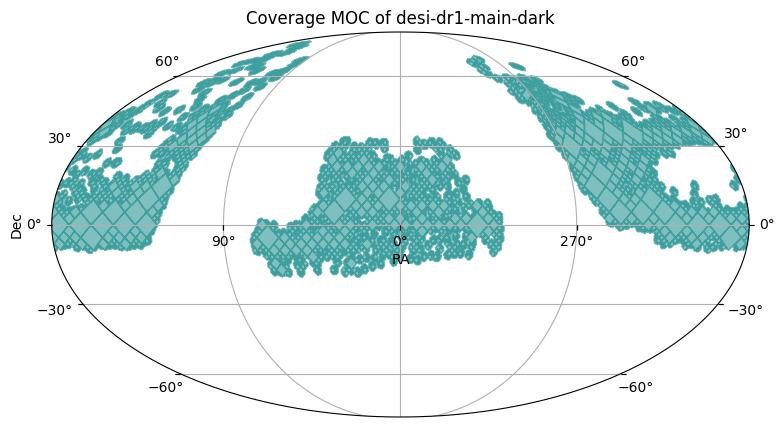

In [31]:
dark_main_catalog.plot_coverage()

In [32]:
df = dark_main_catalog.head(5)
df

TARGETID  TARGET_RA  TARGET_DEC         Z      ZERR  \
_healpix_29                                                                  
24531778214   39627785483846048  45.014136    0.019739  1.308415  0.000399   
76347715933   39627785483846390  45.027565    0.029181  0.884491  0.000116   
79430617729    2714981116149760  45.018964    0.029766  0.129609  0.000009   
88592216842          -110547443  45.028689    0.031667  1.499465  0.000098   
101138674798  39627785483846478  45.030526    0.041094  1.263249   0.00009   

                                                      spectra_b  \
_healpix_29                                                       
24531778214   [{wavelength: 3600.0, flux: 2.924896, ivar: 0....   
76347715933   [{wavelength: 3600.0, flux: -3.560856, ivar: 0...   
79430617729   [{wavelength: 3600.0, flux: -5.12881, ivar: 0....   
88592216842   [{wavelength: 3600.0, flux: 1.824267, ivar: 0....   
101138674798  [{wavelength: 3600.0, flux: 0.314766, ivar: 0....   

                                                      spectra_r  \
_healpix_29                                                       
24531778214   [{wavelength: 5760.0, flux: 1.965631, ivar: 7....   
76347715933   [{wavelength: 5760.0, flux: 0.741585, ivar: 0....   
79430617729   [{wavelength: 5760.0, flux: 0.757192, ivar: 0....   
88592216842   [{wavelength: 5760.0, flux: -0.888818, ivar: 1...   
101138674798  [{wavelength: 5760.0, flux: 0.615158, ivar: 3....   

                                                      spectra_z  
_healpix_29                                                      
24531778214   [{wavelength: 7520.0, flux: 0.379682, ivar: 23...  
76347715933   [{wavelength: 7520.0, flux: -0.305626, ivar: 5...  
79430617729   [{wavelength: 7520.0, flux: 0.227893, ivar: 10...  
88592216842   [{wavelength: 7520.0, flux: -0.377297, ivar: 4...  
101138674798  [{wavelength: 7520.0, flux: 1.088948, ivar: 11...